<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/Deep_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install dependency

In [1]:
!pip install deepagents langchain langchain-openai langchain-groq ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.5/221.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.7/838.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.8 MB/s eta 0:00:00


# import form env

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()
Groq_API= "your api key"
os.environ["GROQ_API_KEY"] = Groq_API

## OpenAI

In [ ]:
from langchain.chat_models import init_chat_model

model=init_chat_model("gpt-4o-mini")
model

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x78865da89b20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x78865d876e40>, root_client=<openai.OpenAI object at 0x78867a78d790>, root_async_client=<openai.AsyncOpenAI object at 0x78865e235df0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'

## Groq api

In [3]:
from langchain.chat_models import init_chat_model

model=init_chat_model("groq:openai/gpt-oss-20b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7e9522d9c5f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7e9522b05160>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

# Deepagent

In [ ]:
from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model = model,
    system_prompt="Act as a researcher"
)

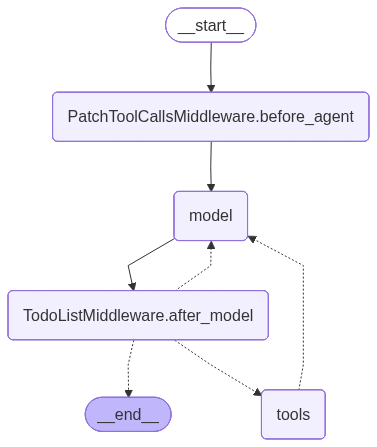

In [ ]:
deepagent

# test

In [ ]:
result = deepagent.invoke({"messages":[{"role":"user","content":"what is langgraph?"}]})

In [ ]:
result

{'messages': [HumanMessage(content='what is langgraph?', additional_kwargs={}, response_metadata={}, id='64360aca-992e-404d-be8c-e1da7fa3b4a6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is langgraph?" They want a definition. Likely a library or framework. We need to answer concisely. Probably a library for building graph-based language models. Let\'s search.', 'tool_calls': [{'id': 'fc_0ff35766-2ecc-41a8-98ea-019734ff15c6', 'function': {'arguments': '{"glob":"**/*.md","output_mode":"content","pattern":"langgraph"}', 'name': 'grep'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 5456, 'total_tokens': 5534, 'completion_time': 0.081195666, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.403538769, 'prompt_tokens_details': None, 'queue_time': 0.045661805, 'total_time': 0.484734435}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 

In [ ]:
result["messages"][-1].content

'**LangGraph** is a framework for building stateful, graph‑driven applications that integrate large language models (LLMs). It lets developers:\n\n- **Model the flow** of an application as a directed graph of nodes (e.g., prompts, tools, decision points).\n- **Maintain state** across steps, so the LLM can refer back to prior context or external data.\n- **Compose complex behaviors** such as multi‑turn conversations, workflows, or decision trees.\n- **Integrate with other systems** (APIs, databases, external tools) through node connectors.\n\nLangGraph focuses on making LLM‑powered workflows more modular, testable, and maintainable by treating the LLM interactions as part of a larger graph structure.'

In [ ]:
result['files']

{}

# Backend for Agents

In [4]:
import os
from deepagents import create_deep_agent
from deepagents.backends import StateBackend

In [30]:
help(StateBackend.__init__)

Help on function __init__ in module deepagents.backends.state:

__init__(self, runtime: object = None, *, file_format: Literal['v1', 'v2'] = 'v2') -> None
    Initialize StateBackend.

    Args:
        runtime: Deprecated - accepted for backward compatibility but
            ignored.  State is now read/written via `get_config()`.
        file_format: Storage format version. `"v1"` stores
            content as `list[str]` (lines split on `\\n`) without an
            `encoding` field.  `"v2"` (default) stores content as a
            plain `str` with an `encoding` field.



In [5]:
agent = create_deep_agent(model=model)

In [6]:
agent2 = create_deep_agent(
    model=model,
    backend=StateBackend(),
)

In [7]:
result = agent2.invoke(
    {
        "messages": [
            {"role": "user",
             "content": (
                 "create a file at /content/agent.txt with exactly this content:\n "
                 "1. record video\n 2. edit video\n 3.upload video.\n"
                 " Then tell me you have done it"
             )
             },
        ]
    }
)

In [8]:
result

{'messages': [HumanMessage(content='create a file at /content/agent.txt with exactly this content:\n 1. record video\n 2. edit video\n 3.upload video.\n Then tell me you have done it', additional_kwargs={}, response_metadata={}, id='6d485861-4722-4aeb-ac7a-6a4ee6673302'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to create a file at /content/agent.txt with exactly that content. Then inform that done. We need to use write_file tool. Provide content with line breaks and spaces exactly as shown. Let\'s ensure formatting: " 1. record video\\n 2. edit video\\n 3.upload video." There\'s a space before each number. The third line has no space after number? It\'s "3.upload video." So we replicate exactly. Let\'s create file.', 'tool_calls': [{'id': 'fc_a02ce972-cc63-41be-884e-e1694ec51082', 'function': {'arguments': '{"content":" 1. record video\\n 2. edit video\\n 3.upload video.","file_path":"/content/agent.txt"}', 'name': 'write_file'}, 'type': 'function'}]

In [9]:
result["messages"][-1].content

'File `/content/agent.txt` created.'

In [10]:
result["files"]

{'/content/agent.txt': {'content': ' 1. record video\n 2. edit video\n 3.upload video.',
  'encoding': 'utf-8',
  'created_at': '2026-06-07T18:51:52.530962+00:00',
  'modified_at': '2026-06-07T18:51:52.530962+00:00'}}

In [11]:
check_file = agent2.invoke({
    "massages":result["messages"]+[{
        "role": "user",
        "content": "read /content/agent.txt back to me."
    }],
    "files":result.get("files",{}),
})

In [12]:
check_file

{'messages': [AIMessage(content='I’m ready to help. What would you like to do?', additional_kwargs={'reasoning_content': "User hasn't asked yet. The system says to respond with tool calls or answer. There's no user input. We need to await user."}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 5442, 'total_tokens': 5492, 'completion_time': 0.05119099, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.023089082, 'prompt_tokens_details': {'cached_tokens': 5376}, 'queue_time': 0.046938234, 'total_time': 0.074280072}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea372-3d75-7490-a651-bcd19cc741e8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5442, 'output_tokens': 50, 'total_tokens': 5492, 'input_token_details': {'cache_read': 5376}, 'output_token_details': {'reasoning':

In [13]:
check_file["messages"][-1].content

'I’m ready to help. What would you like to do?'

# File system

In [18]:
import deepagents.backends
print(dir(deepagents.backends))

['BackendContext', 'BackendProtocol', 'CompositeBackend', 'ContextHubBackend', 'DEFAULT_EXECUTE_TIMEOUT', 'FilesystemBackend', 'LangSmithSandbox', 'LocalShellBackend', 'NamespaceFactory', 'StateBackend', 'StoreBackend', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'composite', 'context_hub', 'filesystem', 'langsmith', 'local_shell', 'protocol', 'sandbox', 'state', 'store', 'utils']


In [28]:
from deepagents.backends import FilesystemBackend
help(FilesystemBackend.__init__)

Help on function __init__ in module deepagents.backends.filesystem:

__init__(self, root_dir: str | pathlib.Path | None = None, virtual_mode: bool | None = None, max_file_size_mb: int = 10) -> None
    Initialize filesystem backend.

    Args:
        root_dir: Optional root directory for file operations.

            Defaults to the current working directory.

            - When `virtual_mode=False` (default): Only affects relative path resolution.
            - When `virtual_mode=True`: Acts as a virtual root for filesystem operations.

        virtual_mode: Enable virtual path mode.

            **Primary use case:** stable, backend-independent path semantics when
            used with `CompositeBackend`, which strips route prefixes and forwards
            normalized paths to the routed backend.

            When `True`, all paths are treated as virtual paths anchored to
            `root_dir`. Path traversal (`..`, `~`) is blocked and all resolved paths
            are verified to

In [22]:
from deepagents.backends import FilesystemBackend

ROOT="/content"

agent3 = create_deep_agent(model=model, backend=FilesystemBackend(root_dir=ROOT, virtual_mode=True))

In [31]:
result = agent3.invoke(
    {
        "messages": [
            {"role": "user",
             "content": (
                 "create a file at /content/agent.txt with exactly this content:\n "
                 "1. record video\n 2. edit video\n 3.upload video.\n"
                 " Then tell me you have done it"
             )
             },
        ]
    }
)

In [32]:
result

{'messages': [HumanMessage(content='create a file at /content/agent.txt with exactly this content:\n 1. record video\n 2. edit video\n 3.upload video.\n Then tell me you have done it', additional_kwargs={}, response_metadata={}, id='86340796-fd99-4ca1-be02-18186ad4ed53'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to create a file at /content/agent.txt with exact content. Need to use write_file. After writing, tell them. No need for todos. Just write file.', 'tool_calls': [{'id': 'fc_25011b92-ab64-4454-8a94-6d5c71f971ff', 'function': {'arguments': '{"content":" 1. record video\\n 2. edit video\\n 3.upload video.","file_path":"/content/agent.txt"}', 'name': 'write_file'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 5484, 'total_tokens': 5569, 'completion_time': 0.09010621, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.432889813, 'prompt_tokens_details': None, 'queue_time': 

In [36]:
result['messages'][-1].usage_metadata

{'input_tokens': 5542,
 'output_tokens': 31,
 'total_tokens': 5573,
 'input_token_details': {'cache_read': 5376},
 'output_token_details': {'reasoning': 13}}